# **Network Intrusion Detection System using Machine Learning**

## Machine Learning Project

Dataset:
CICIDS2017

Models:
• Decision Tree
• SVM
• MLP
• Random Forest
• XGBoost
• LightGBM

Objective:
Develop and evaluate a machine learning–based Network Intrusion Detection System (NIDS) using the CICIDS2017 dataset and compare multiple classification models with explainable AI techniques.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install xgboost lightgbm shap -q

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/NIDS_Project/cleaned_dataset.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully!
Shape: (2520798, 79)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Development Mode

DEVELOPMENT_MODE = True

if DEVELOPMENT_MODE:
    df = df.sample(n=50000, random_state=42)

print("Working Dataset Shape:", df.shape)

Working Dataset Shape: (50000, 79)


In [ ]:
# Features and Target

X = df.drop("Label", axis=1)
y = df["Label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (50000, 78)
Target Shape: (50000,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Label Encoding Completed!")

Label Encoding Completed!


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (30000, 78)
Testing Shape: (20000, 78)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


# Evaluation Function

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate(model, X_test, y_test, name):

    y_pred = model.predict(X_test)

    print("\n", "-"*35)
    print(name)
    print("-"*35)

    print("Accuracy :", round(accuracy_score(y_test, y_pred)*100,2), "%")
    print("Precision :", round(precision_score(y_test, y_pred, average="weighted", zero_division=0),4))
    print("Recall :", round(recall_score(y_test, y_pred, average="weighted", zero_division=0),4))
    print("F1 Score :", round(f1_score(y_test, y_pred, average="weighted", zero_division=0),4))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

evaluate(dt, X_test, y_test, "Decision Tree")


 -----------------------------------
Decision Tree
-----------------------------------
Accuracy : 99.41 %
Precision : 0.9946
Recall : 0.9941
F1 Score : 0.9943

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16635
           1       0.39      0.60      0.47        15
           2       1.00      0.99      1.00      1000
           3       0.88      0.95      0.91        91
           4       0.99      0.99      0.99      1353
           5       0.73      0.92      0.82        39
           6       0.87      0.95      0.91        43
           7       1.00      1.00      1.00        42
           8       0.99      0.98      0.98       740
           9       0.96      0.96      0.96        26
          10       0.73      0.80      0.76        10
          11       0.50      0.33      0.40         6

    accuracy                           0.99     20000
   macro avg       0.84      0.87      0.85     20000
wei

# SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", random_state=42)

svm.fit(X_train_scaled, y_train)

evaluate(svm, X_test_scaled, y_test, "SVM")


 -----------------------------------
SVM
-----------------------------------
Accuracy : 96.56 %
Precision : 0.9637
Recall : 0.9656
F1 Score : 0.9635

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     16635
           1       0.00      0.00      0.00        15
           2       0.99      0.86      0.92      1000
           3       0.94      0.80      0.86        91
           4       0.99      0.91      0.95      1353
           5       0.89      0.79      0.84        39
           6       1.00      0.58      0.74        43
           7       0.00      0.00      0.00        42
           8       0.74      0.97      0.84       740
           9       0.00      0.00      0.00        26
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00         6

    accuracy                           0.97     20000
   macro avg       0.54      0.49      0.51     20000
weighted avg 

# MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

evaluate(mlp, X_test_scaled, y_test, "MLP")


 -----------------------------------
MLP
-----------------------------------
Accuracy : 99.28 %
Precision : 0.9921
Recall : 0.9929
F1 Score : 0.9923

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     16635
           1       1.00      0.27      0.42        15
           2       1.00      0.99      1.00      1000
           3       0.99      0.93      0.96        91
           4       0.99      0.95      0.97      1353
           5       0.89      1.00      0.94        39
           6       0.98      0.93      0.95        43
           7       1.00      1.00      1.00        42
           8       0.99      0.99      0.99       740
           9       1.00      0.96      0.98        26
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00         6

    accuracy                           0.99     20000
   macro avg       0.82      0.75      0.77     20000
weighted avg 

# Random Forest(First Improvement)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

evaluate(rf, X_test, y_test, "Random Forest")


 -----------------------------------
Random Forest
-----------------------------------
Accuracy : 99.66 %
Precision : 0.9962
Recall : 0.9966
F1 Score : 0.9963

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16635
           1       0.86      0.40      0.55        15
           2       1.00      1.00      1.00      1000
           3       1.00      0.95      0.97        91
           4       1.00      0.99      0.99      1353
           5       0.95      0.97      0.96        39
           6       1.00      0.91      0.95        43
           7       1.00      1.00      1.00        42
           8       0.99      0.99      0.99       740
           9       1.00      0.92      0.96        26
          10       0.60      0.30      0.40        10
          11       0.00      0.00      0.00         6

    accuracy                           1.00     20000
   macro avg       0.87      0.79      0.81     20000
wei

In [ ]:
!pip install xgboost

# XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

evaluate(xgb, X_test, y_test, "XGBoost")


 -----------------------------------
XGBoost
-----------------------------------
Accuracy : 99.8 %
Precision : 0.998
Recall : 0.998
F1 Score : 0.998

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16635
           1       0.92      0.73      0.81        15
           2       1.00      1.00      1.00      1000
           3       0.99      0.96      0.97        91
           4       1.00      0.99      1.00      1353
           5       0.97      1.00      0.99        39
           6       1.00      0.98      0.99        43
           7       1.00      1.00      1.00        42
           8       0.99      1.00      0.99       740
           9       1.00      0.96      0.98        26
          10       0.75      0.30      0.43        10
          11       0.44      0.67      0.53         6

    accuracy                           1.00     20000
   macro avg       0.92      0.88      0.89     20000
weighted avg 

# LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=12,
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

evaluate(lgbm, X_test, y_test, "LightGBM")


 -----------------------------------
LightGBM
-----------------------------------
Accuracy : 92.81 %
Precision : 0.9494
Recall : 0.9281
F1 Score : 0.9384

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96     16635
           1       0.00      0.00      0.00        15
           2       0.92      0.85      0.89      1000
           3       0.58      0.48      0.53        91
           4       0.86      0.78      0.82      1353
           5       0.00      0.00      0.00        39
           6       0.00      0.00      0.00        43
           7       0.05      0.05      0.05        42
           8       0.95      0.91      0.93       740
           9       0.00      0.00      0.00        26
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00         6

    accuracy                           0.93     20000
   macro avg       0.36      0.34      0.35     20000
weighted

In [ ]:
results = {
    "Decision Tree": {
        "Accuracy": 99.41,
        "Precision": 0.9946,
        "Recall": 0.9941,
        "F1 Score": 0.9943
    },
    "SVM": {
        "Accuracy": 96.56,
        "Precision": 0.9637,
        "Recall": 0.9656,
        "F1 Score": 0.9635
    },
    "MLP": {
        "Accuracy": 99.28,
        "Precision": 0.9921,
        "Recall": 0.9929,
        "F1 Score": 0.9923
    },
    "Random Forest": {
        "Accuracy": 99.66,
        "Precision": 0.9962,
        "Recall": 0.9966,
        "F1 Score": 0.9963
    },
    "XGBoost": {
        "Accuracy": 99.80,
        "Precision": 0.9980,
        "Recall": 0.9980,
        "F1 Score": 0.9980
    },
    "LightGBM": {
        "Accuracy": 92.81,
        "Precision": 0.9494,
        "Recall": 0.9281,
        "F1 Score": 0.9384
    }
}

In [ ]:
comparison = pd.DataFrame(results).T

comparison

,Accuracy,Precision,Recall,F1 Score
Decision Tree,99.41,0.9946,0.9941,0.9943
SVM,96.56,0.9637,0.9656,0.9635
MLP,99.28,0.9921,0.9929,0.9923
Random Forest,99.66,0.9962,0.9966,0.9963
XGBoost,99.80,0.9980,0.9980,0.9980
LightGBM,92.81,0.9494,0.9281,0.9384


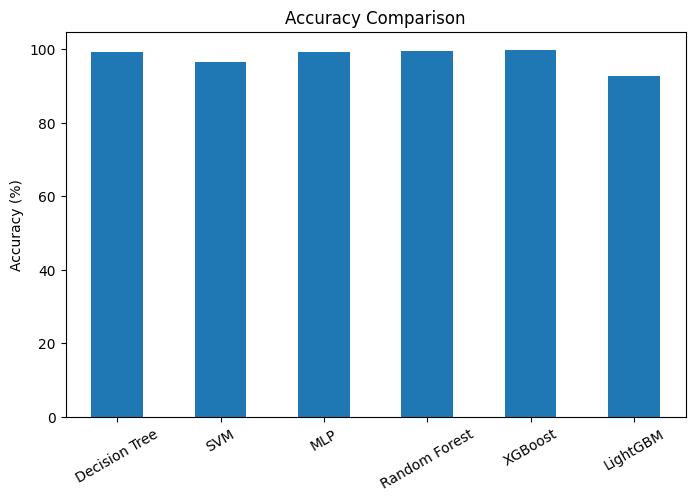

In [ ]:
comparison["Accuracy"].plot(kind="bar", figsize=(8,5))

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)

plt.show()

# Precision Comparison

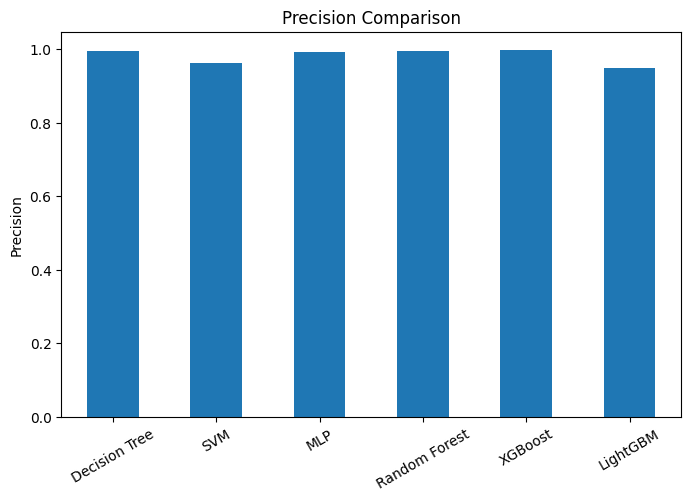

In [ ]:
comparison["Precision"].plot(kind="bar", figsize=(8,5))

plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.xticks(rotation=30)

plt.show()

# Recall Comparison

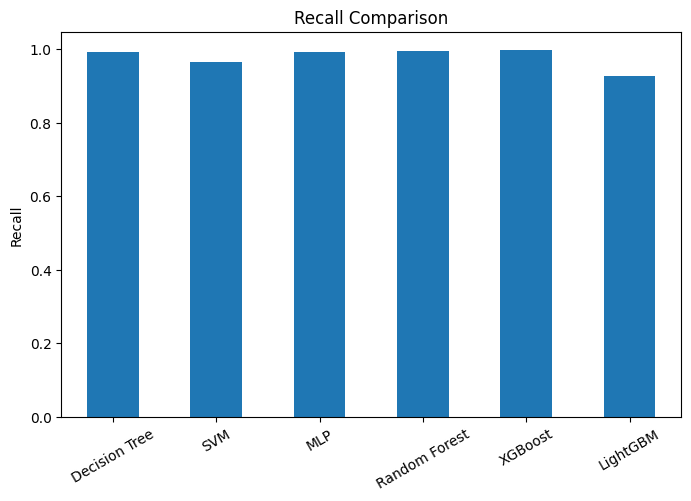

In [ ]:
comparison["Recall"].plot(kind="bar", figsize=(8,5))

plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.xticks(rotation=30)

plt.show()

# F1-Score Comparison

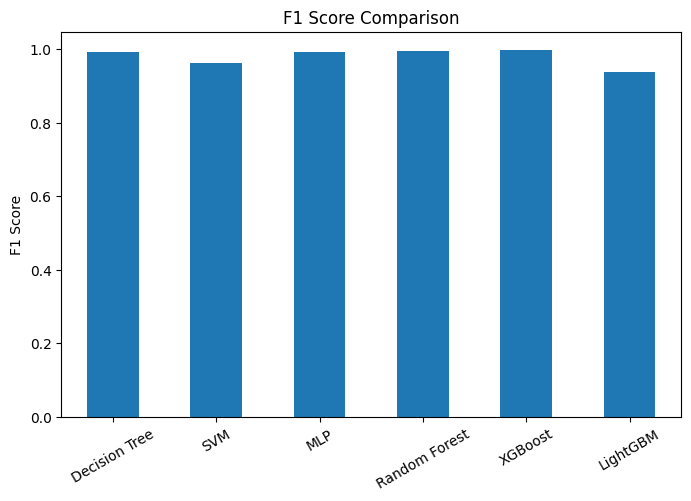

In [ ]:
comparison["F1 Score"].plot(kind="bar", figsize=(8,5))

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)

plt.show()

# Feature Importance Analysis

Feature importance helps identify the most influential network traffic features used by tree-based machine learning models for intrusion detection.

# Decision Tree Feature Importance

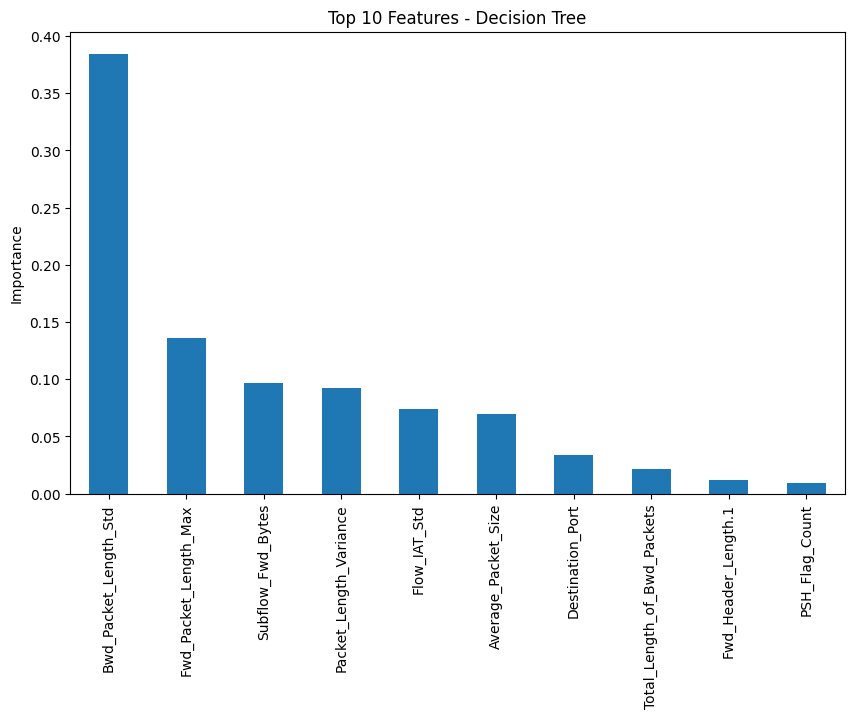

Bwd_Packet_Length_Std          0.384474
Fwd_Packet_Length_Max          0.135887
Subflow_Fwd_Bytes              0.097093
Packet_Length_Variance         0.091912
Flow_IAT_Std                   0.073796
Average_Packet_Size            0.069623
Destination_Port               0.033651
Total_Length_of_Bwd_Packets    0.021827
Fwd_Header_Length.1            0.011701
PSH_Flag_Count                 0.008937
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dt_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
dt_importance.head(10).plot(kind="bar")

plt.title("Top 10 Features - Decision Tree")
plt.ylabel("Importance")
plt.show()

print(dt_importance.head(10))

# Random Forest Feature Importance

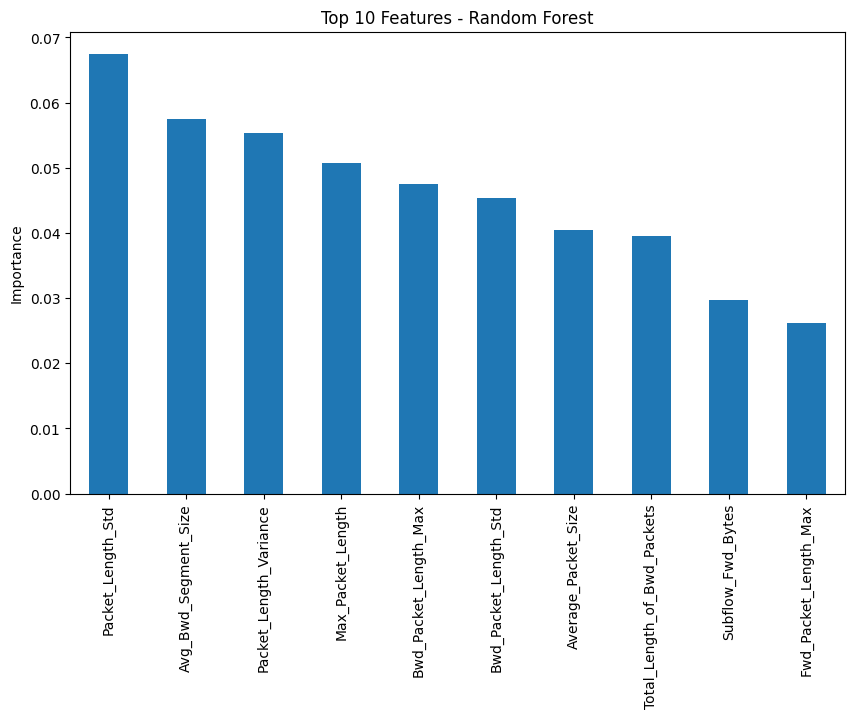

Packet_Length_Std              0.067504
Avg_Bwd_Segment_Size           0.057411
Packet_Length_Variance         0.055328
Max_Packet_Length              0.050791
Bwd_Packet_Length_Max          0.047441
Bwd_Packet_Length_Std          0.045322
Average_Packet_Size            0.040451
Total_Length_of_Bwd_Packets    0.039594
Subflow_Fwd_Bytes              0.029741
Fwd_Packet_Length_Max          0.026160
dtype: float64


In [ ]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
rf_importance.head(10).plot(kind="bar")

plt.title("Top 10 Features - Random Forest")
plt.ylabel("Importance")
plt.show()

print(rf_importance.head(10))

# XGBoost Feature Importance

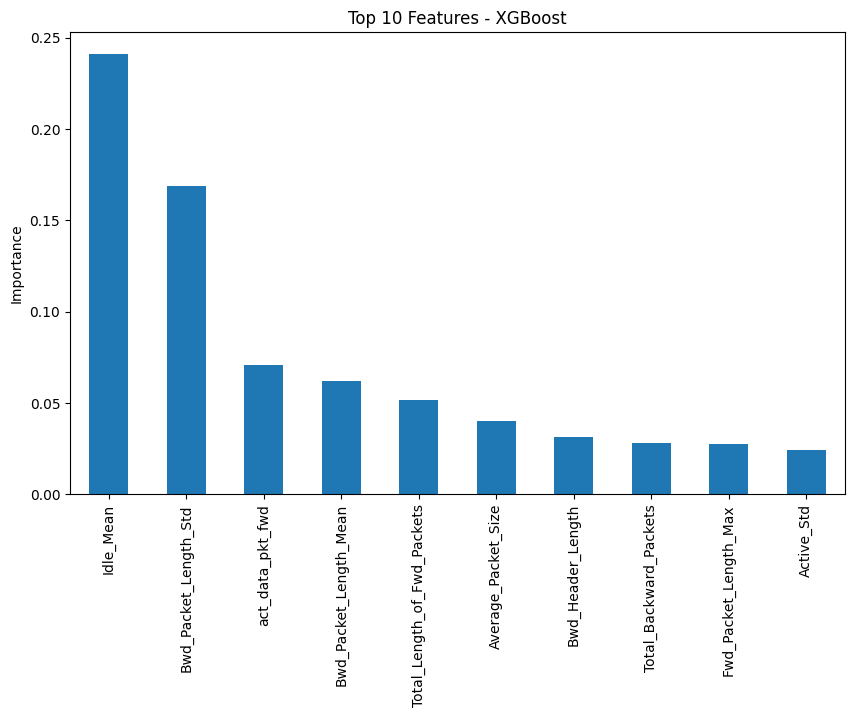

Idle_Mean                      0.240878
Bwd_Packet_Length_Std          0.168686
act_data_pkt_fwd               0.071019
Bwd_Packet_Length_Mean         0.062241
Total_Length_of_Fwd_Packets    0.051665
Average_Packet_Size            0.040386
Bwd_Header_Length              0.031496
Total_Backward_Packets         0.027813
Fwd_Packet_Length_Max          0.027300
Active_Std                     0.024036
dtype: float32


In [ ]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
xgb_importance.head(10).plot(kind="bar")

plt.title("Top 10 Features - XGBoost")
plt.ylabel("Importance")
plt.show()

print(xgb_importance.head(10))

# SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to explain the predictions of the best-performing machine learning model (XGBoost). It identifies how each feature contributes to the model's prediction, improving transparency and interpretability.

In [ ]:
!pip install shap -q

import shap


In [ ]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot

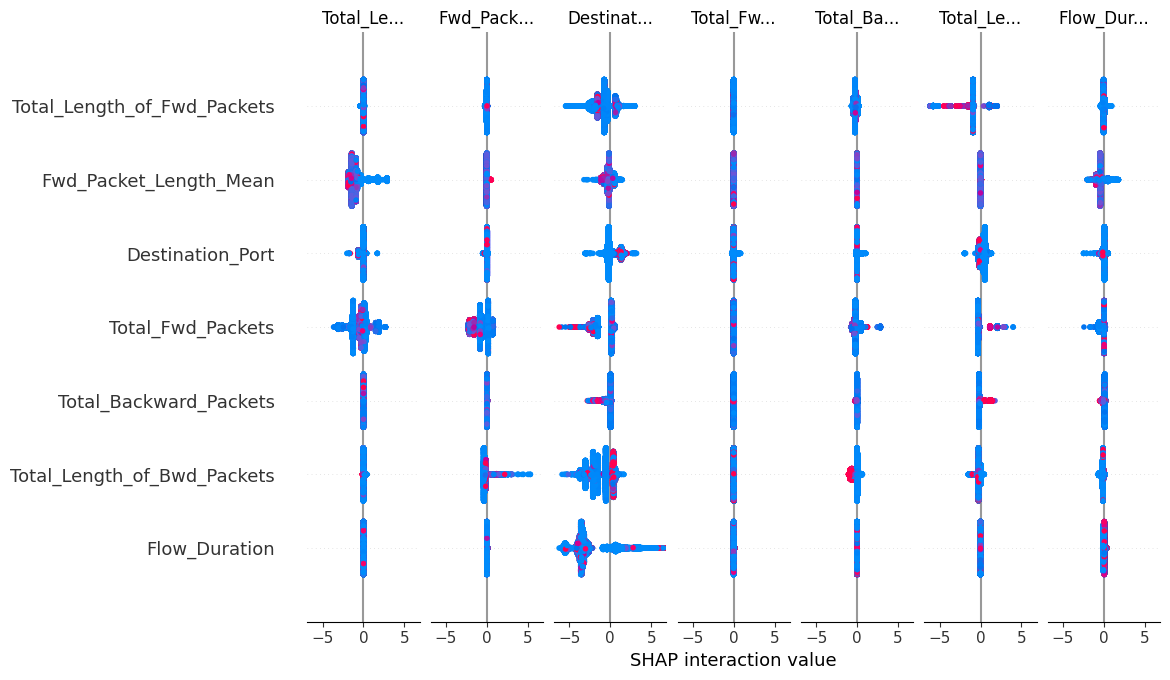

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

# SHAP Bar Plot

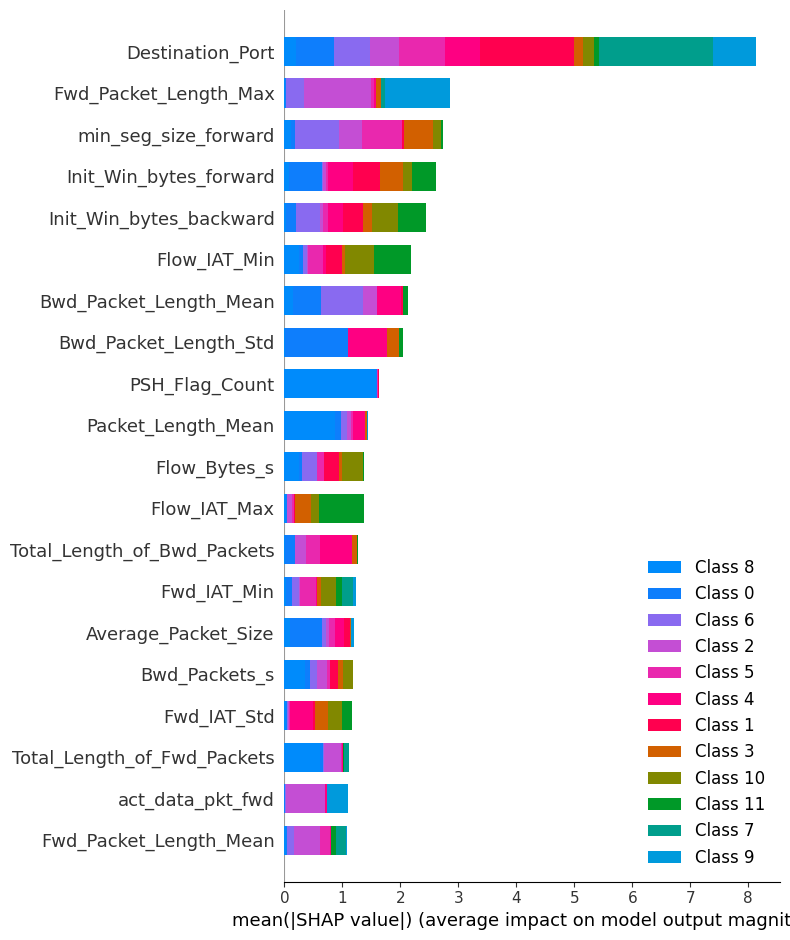

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

# SHAP Force Plot (Single Prediction)

In [ ]:
sample_index = 0
class_index = 0

shap.initjs()

shap.force_plot(
    explainer.expected_value[class_index],
    shap_values[sample_index, :, class_index],
    X_test.iloc[sample_index]
)

# Confusion Matrix Analysis

A confusion matrix is used to evaluate the classification performance of each machine learning model. It compares the actual class labels with the predicted class labels, helping identify correctly classified instances and misclassifications.

# Function to Plot Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(12,10))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False
    )

    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(fontsize=9)

    plt.title(f"{model_name} Confusion Matrix", fontsize=14)

    plt.tight_layout()

    plt.show()

# Decision Tree

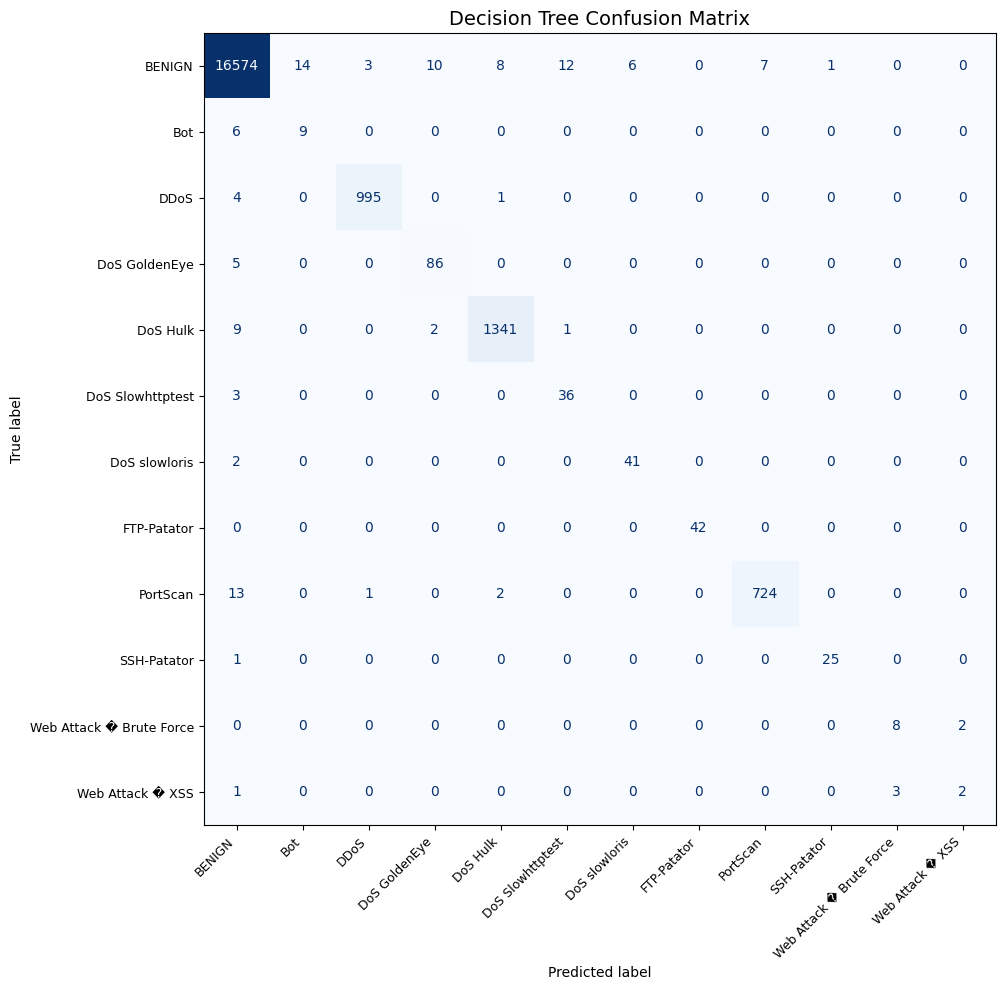

In [ ]:
plot_confusion_matrix(dt, X_test, y_test, "Decision Tree")

# SVM

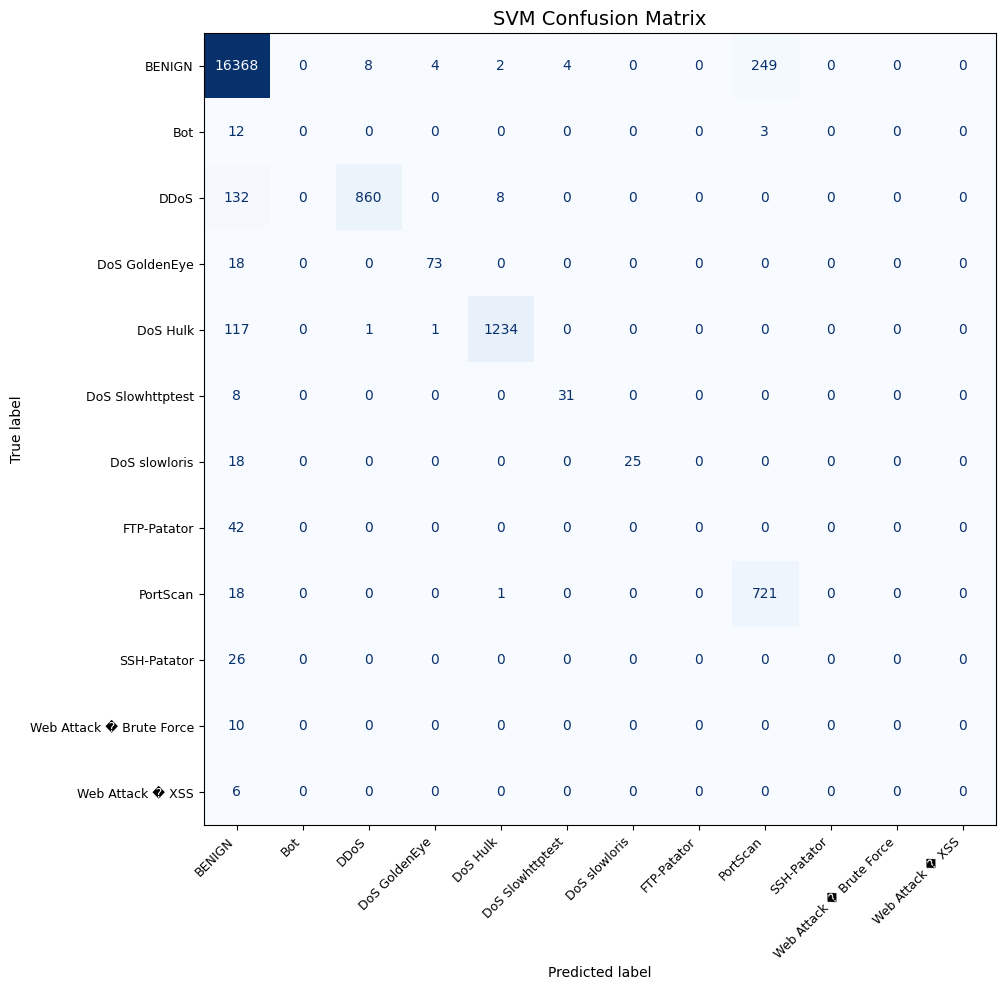

In [ ]:
plot_confusion_matrix(svm, X_test_scaled, y_test, "SVM")

# MLP

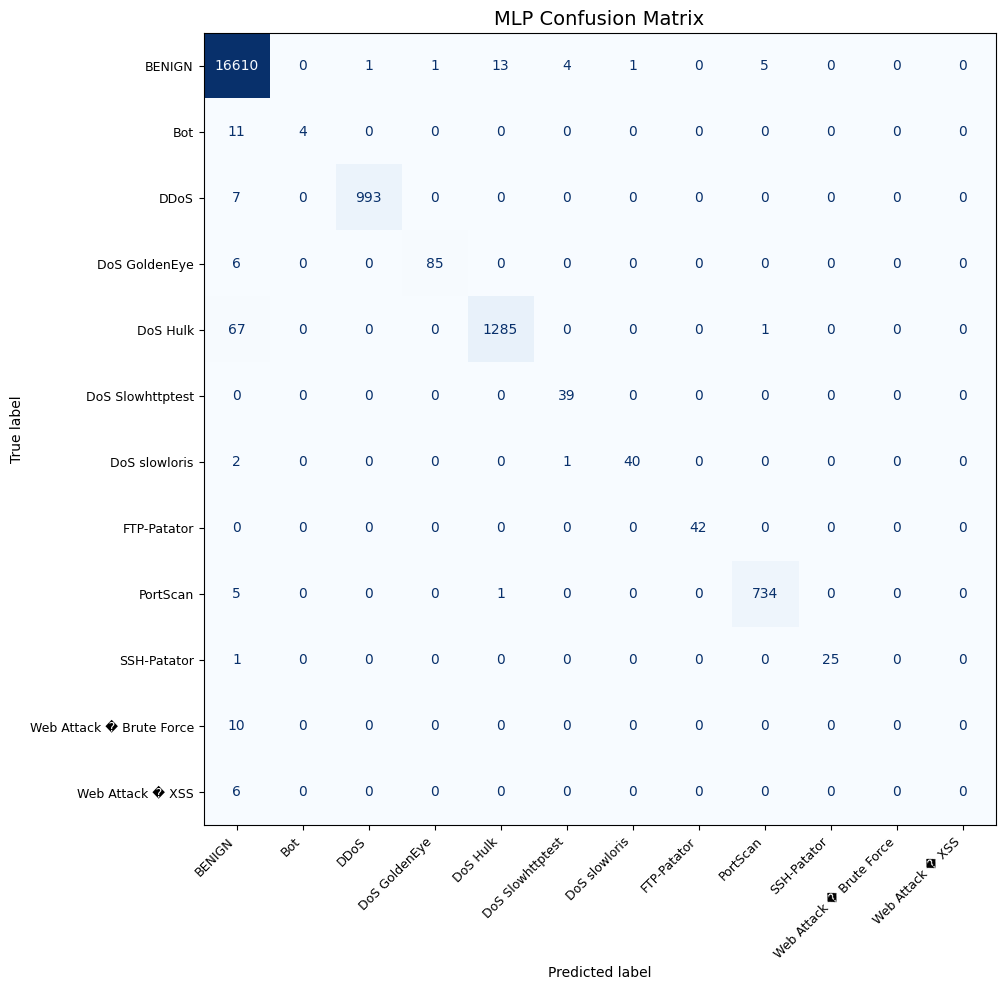

In [ ]:
plot_confusion_matrix(mlp, X_test_scaled, y_test, "MLP")

# Random Forest

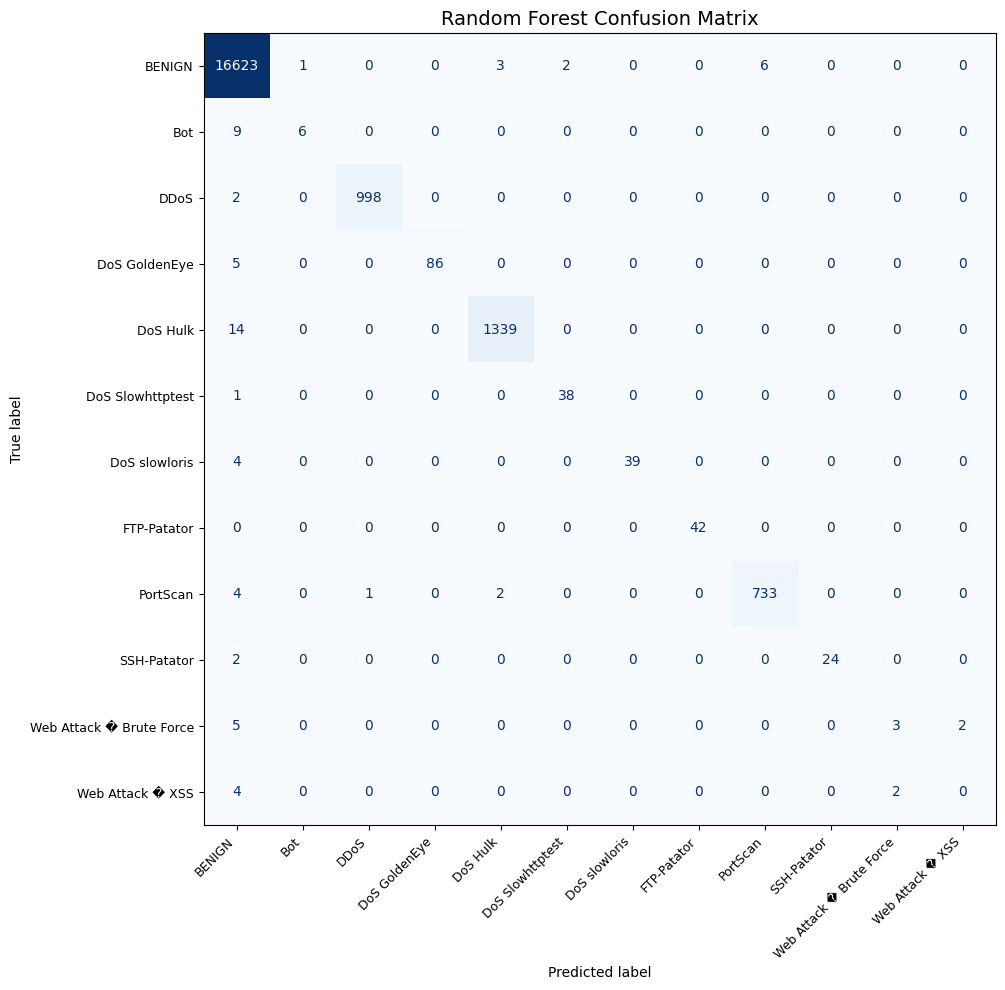

In [ ]:
plot_confusion_matrix(rf, X_test, y_test, "Random Forest")

# XGBoost

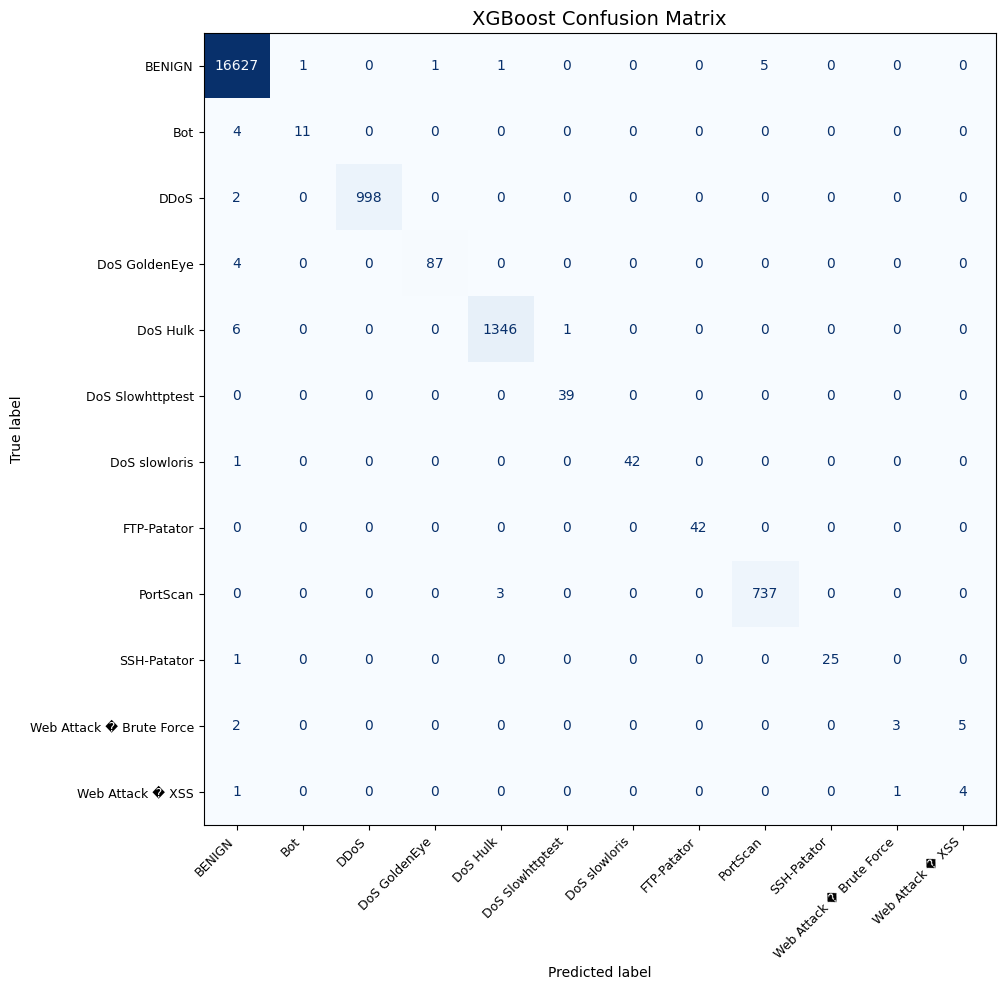

In [ ]:
plot_confusion_matrix(xgb, X_test, y_test, "XGBoost")

# LightGBM

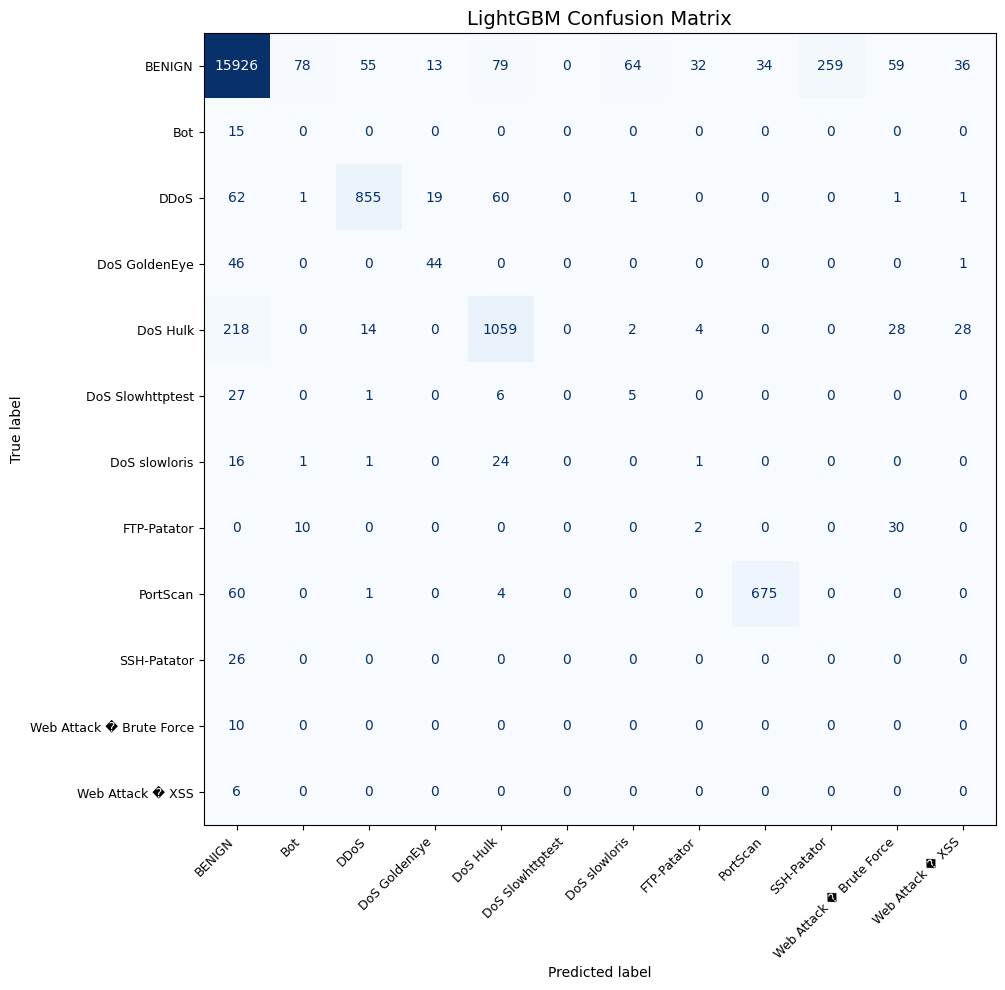

In [ ]:
plot_confusion_matrix(lgbm, X_test, y_test, "LightGBM")

# Comparison with the Research Paper

The proposed system reproduces the baseline models presented in the research paper and extends the work by implementing additional machine learning models, comprehensive data analysis, feature importance analysis, and explainable AI techniques.

In [ ]:
comparison_paper = pd.DataFrame({
    "Research Paper": [
        "CICIDS2017",
        "MATLAB + KNIME",
        "Decision Tree, SVM, MLP",
        "Decision Tree (94.72%)",
        "60:40",
        "Accuracy, Precision, Recall, F1",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],
    "Our Implementation": [
        "CICIDS2017",
        "Python (Pandas, Scikit-learn, XGBoost, LightGBM)",
        "Decision Tree, SVM, MLP, Random Forest, XGBoost, LightGBM",
        "XGBoost (99.80%)",
        "60:40",
        "Accuracy, Precision, Recall, F1-score, Classification Report",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
},
index=[
    "Dataset",
    "Implementation Platform",
    "Models",
    "Best Model",
    "Train-Test Split",
    "Evaluation Metrics",
    "Exploratory Data Analysis",
    "Feature Importance",
    "Model Comparison",
    "SHAP Explainability",
    "Advanced Ensemble Models"
])

comparison_paper

,Research Paper,Our Implementation
Dataset,CICIDS2017,CICIDS2017
Implementation Platform,MATLAB + KNIME,"Python (Pandas, Scikit-learn, XGBoost, LightGBM)"
Models,"Decision Tree, SVM, MLP","Decision Tree, SVM, MLP, Random Forest, XGBoos..."
Best Model,Decision Tree (94.72%),XGBoost (99.80%)
Train-Test Split,60:40,60:40
Evaluation Metrics,"Accuracy, Precision, Recall, F1","Accuracy, Precision, Recall, F1-score, Classif..."
Exploratory Data Analysis,No,Yes
Feature Importance,No,Yes
Model Comparison,No,Yes
SHAP Explainability,No,Yes


# Conclusion

In [ ]:
print("""
Conclusion

This project successfully reproduced the Network Intrusion Detection System
presented in the research paper using the CICIDS2017 dataset.

The baseline machine learning models (Decision Tree, SVM, and MLP)
were implemented and evaluated.

To improve the existing work, three additional ensemble models
(Random Forest, XGBoost, and LightGBM) were implemented.

Among all evaluated models, XGBoost achieved the highest accuracy
of 99.80%, outperforming the baseline models.

Furthermore, SHAP explainability and feature importance analysis
were incorporated to improve the transparency and interpretability
of the intrusion detection system.

Overall, the proposed implementation demonstrates that modern
ensemble learning techniques can improve intrusion detection
performance while providing better model interpretability.
""")


Conclusion

This project successfully reproduced the Network Intrusion Detection System
presented in the research paper using the CICIDS2017 dataset.

The baseline machine learning models (Decision Tree, SVM, and MLP)
were implemented and evaluated.

To improve the existing work, three additional ensemble models
(Random Forest, XGBoost, and LightGBM) were implemented.

Among all evaluated models, XGBoost achieved the highest accuracy
of 99.80%, outperforming the baseline models.

Furthermore, SHAP explainability and feature importance analysis
were incorporated to improve the transparency and interpretability
of the intrusion detection system.

Overall, the proposed implementation demonstrates that modern
ensemble learning techniques can improve intrusion detection
performance while providing better model interpretability.

